# 03 — Baseline Prediction & Inference

Validate the model's performance on unseen data by visualizing predictions against ground truth labels.  

**Prerequisite:** A trained model file promoted to `artifacts/checkpoints/baseline_cnn_best.keras`.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from model_service.config import ModelServiceConfig
from model_service.preprocess.dataset_builder import build_pcam_datasets

# For creating confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

In [14]:
# 1. Load the central configuration
cfg = ModelServiceConfig()

# 2. Point to the "Promoted" model we just renamed
model_path = cfg.paths.artifacts_checkpoints / "baseline_cnn_best.keras"

# 3. Load the full model (Architecture + Weights + Optimizer)
model = tf.keras.models.load_model(model_path)

print(f"✅ Model successfully loaded from {model_path.name}")

✅ Model successfully loaded from baseline_cnn_best.keras


In [15]:
# Load dataset (ignoring train/val)
_, _, test_ds, _ = build_pcam_datasets()

cancer_imgs, healthy_imgs = [], []

# Unbatch allows us to grab individual images until our 5+5 quota is met
for img, label in test_ds.unbatch():
    if label == 1 and len(cancer_imgs) < 5:
        cancer_imgs.append(img)
    elif label == 0 and len(healthy_imgs) < 5:
        healthy_imgs.append(img)
    if len(cancer_imgs) == 5 and len(healthy_imgs) == 5:
        break

X_test = np.array(cancer_imgs + healthy_imgs)
y_true = [1]*5 + [0]*5

2026-04-22 21:05:11.442862: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


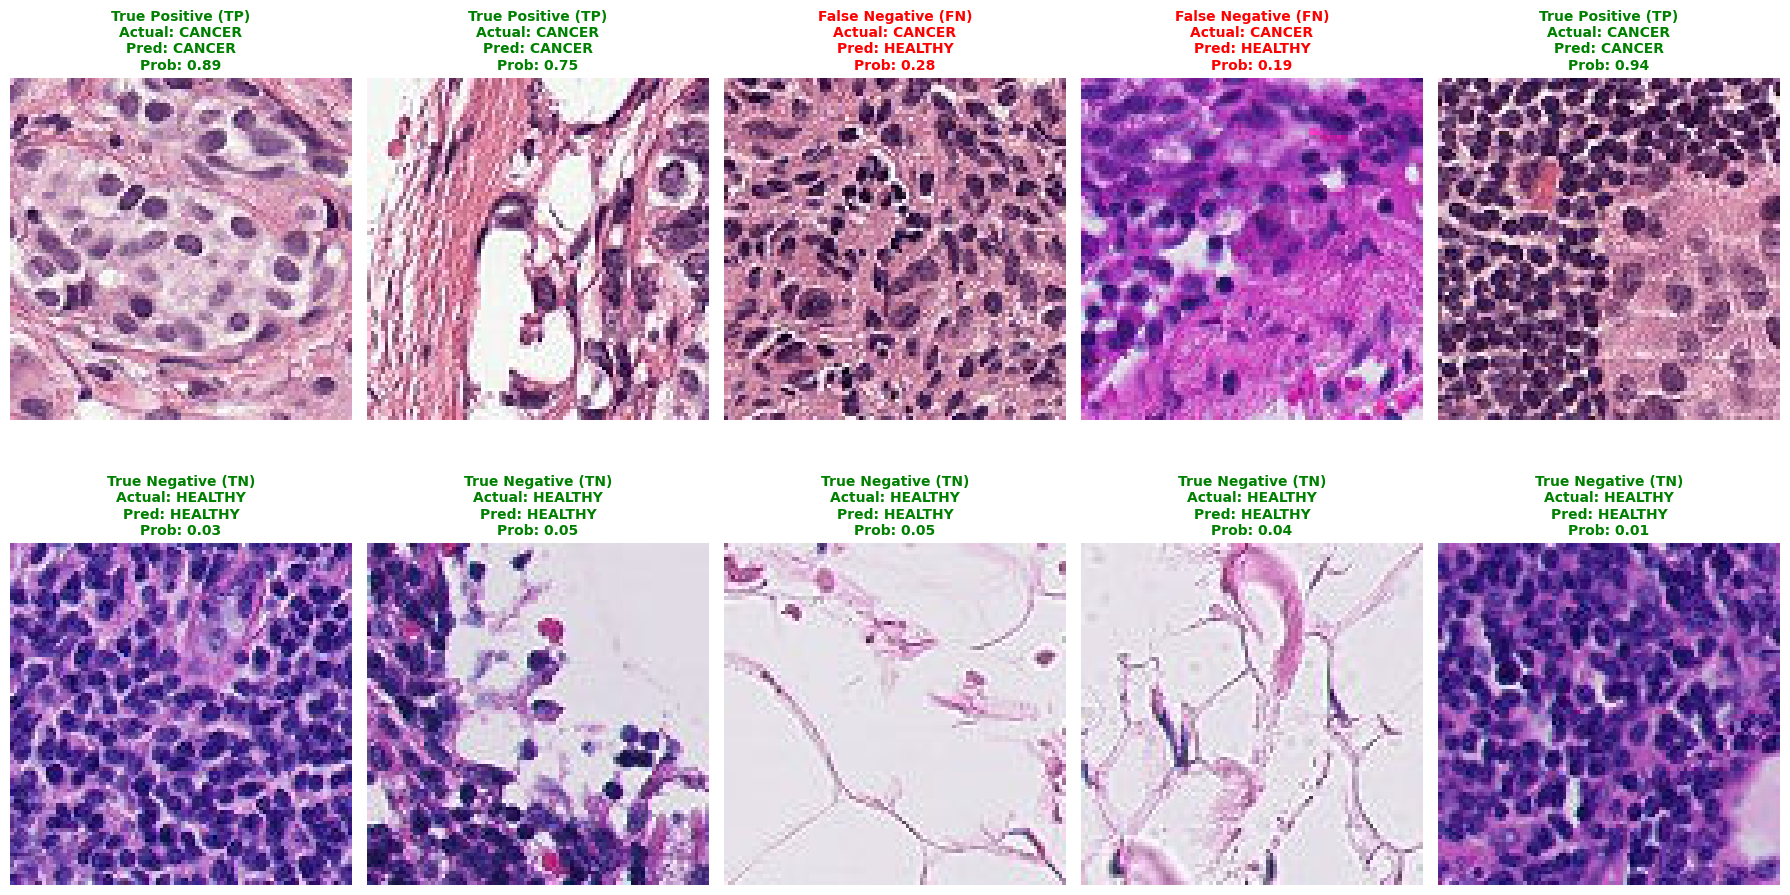

In [ ]:
preds = model.predict(X_test)

plt.figure(figsize=(18, 10))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i])

    prob = float(preds[i][0])
    is_cancer_pred = prob > 0.5
    is_cancer_true = y_true[i] == 1

    # Logic to determine the Technical Term
    if is_cancer_pred and is_cancer_true:
        term = "True Positive (TP)"
        color = 'green'
    elif not is_cancer_pred and not is_cancer_true:
        term = "True Negative (TN)"
        color = 'green'
    elif is_cancer_pred and not is_cancer_true:
        term = "False Positive (FP)"
        color = 'red'
    else: # not is_cancer_pred and is_cancer_true
        term = "False Negative (FN)"
        color = 'red'

    # Display logic
    true_label = "CANCER" if is_cancer_true else "HEALTHY"
    pred_label = "CANCER" if is_cancer_pred else "HEALTHY"

    plt.title(f"{term}\nActual: {true_label}\nPred: {pred_label}\nProb: {prob:.2f}",
              color=color, fontsize=10, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [17]:
# Evaluate on the full unseen test dataset
results = model.evaluate(test_ds, return_dict=True)

print(f"📈 Full Test AUC: {results['auc']:.4f}")
print(f"🔍 Full Test Recall: {results['recall']:.4f}")
print(f"🎯 Full Test Accuracy: {results['accuracy']:.4f}")
print(f"⚠️ Full Test Loss: {results['loss']:.4f}")
print(f"🔍 Full Test Precision: {results['precision']:.4f}")


1024/1024 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.7820 - auc: 0.8910 - loss: 0.4615 - precision: 0.8661 - recall: 0.6640
📈 Full Test AUC: 0.8930
🔍 Full Test Recall: 0.6664
🎯 Full Test Accuracy: 0.7839
⚠️ Full Test Loss: 0.4586
🔍 Full Test Precision: 0.8710


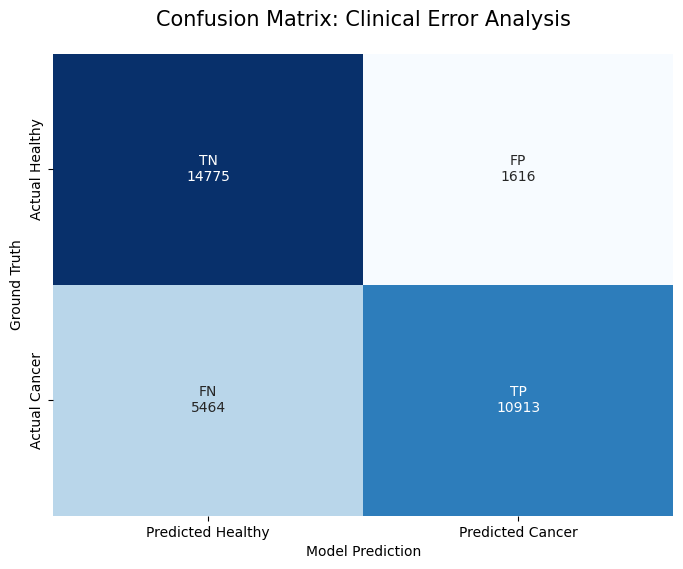

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# 1. Generate the raw confusion matrix
cm = confusion_matrix(y_true_all, y_pred_all)

# 2. Define the labels for each quadrant
# We create a 2x2 array of strings to overlay on the heatmap
box_labels = np.asarray([
    [f"TN\n{cm[0,0]}", f"FP\n{cm[0,1]}"],
    [f"FN\n{cm[1,0]}", f"TP\n{cm[1,1]}"]
])

# 3. Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=box_labels, fmt="", cmap='Blues', cbar=False,
            xticklabels=['Predicted Healthy', 'Predicted Cancer'],
            yticklabels=['Actual Healthy', 'Actual Cancer'])

plt.title('Confusion Matrix: Clinical Error Analysis', fontsize=15, pad=20)
plt.ylabel('Ground Truth')
plt.xlabel('Model Prediction')
plt.show()

In [ ]:
def interpret_results(results):
    auc = results.get('auc', 0)
    recall = results.get('recall', 0)
    precision = results.get('precision', 0)

    print(f"### 🤖 Automated Model Audit")

    # Logic for AUC
    if auc > 0.95:
        print(f"- **Overall Power:** Excellent ({auc:.2f}). This model is near production-ready.")
    elif auc > 0.85:
        print(f"- **Overall Power:** Strong ({auc:.2f}). Good separation, but room for refinement.")
    else:
        print(f"- **Overall Power:** Baseline ({auc:.2f}). Needs structural improvements.")

    # Logic for the Precision/Recall Trade-off
    if recall < precision - 0.15:
        print(f"- **Clinical Bias:** ⚠️ **CONSERVATIVE**. High Precision ({precision:.2f}) but low Recall ({recall:.2f}). "
              "The model is missing too many cases. Consider lowering the decision threshold.")
    elif recall > precision + 0.15:
        print(f"- **Clinical Bias:** 🚩 **AGGRESSIVE**. High Recall ({recall:.2f}) but low Precision ({precision:.2f}). "
              "The model is over-diagnosing. High rate of false alarms.")
    else:
        print(f"- **Clinical Bias:** ⚖️ **BALANCED**. Precision and Recall are aligned. Stable performance.")

# Call it using your 'results' dictionary from model.evaluate()
interpret_results(results)

### 🤖 Automated Model Audit
- **Overall Power:** Strong (0.89). Good separation, but room for refinement.
- **Clinical Bias:** ⚠️ **CONSERVATIVE**. High Precision (0.87) but low Recall (0.67). The model is missing too many cases. Consider lowering the decision threshold.
